# 传感器数据的层次聚类（凝聚式）教学案例

**知识点简述**

层次聚类（凝聚式）是一类自底向上的聚类方法：把每个样本先看作一个簇，然后不断合并“最相似”的簇，直到达到指定的簇数或停止条件。与 K-Means 不同，它不需要先假设簇的形状，也能通过树状图（dendrogram）观察不同层次的聚合过程。

**设计程序的意义**

在传感器数据场景中，层次聚类可以帮助我们：

- 发现设备或环境状态的潜在分组
- 识别异常模式或“相似运行状态”的簇
- 为后续的分类、报警或设备维护策略提供依据

下面通过一个可复现实验：生成数据、保存到 `data/` 目录、标准化、计算链接矩阵并可视化、完成聚类与结果解读。

## 实验流程

1. 生成并保存传感器数据集到 `data/` 目录
2. 读取数据、查看基本统计信息
3. 标准化特征，计算层次聚类的链接矩阵
4. 绘制树状图，选择簇数
5. 训练凝聚式层次聚类模型并可视化结果
6. 小结与拓展思考

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

np.random.seed(42)

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

print("data dir:", data_dir.resolve())

data dir: D:\xiangmu\j11-chuanganqi\data


## 1. 生成模拟传感器数据并保存

我们模拟 4 个传感器特征：温度、湿度、振动、压力，并人为构造 3 种运行状态（3 个簇）。随后保存为 CSV，方便教学时“从数据文件读取”的流程演示。

In [2]:
n_per_cluster = 120

# 三个簇的中心 (温度, 湿度, 振动, 压力)
centers = np.array([
    [22, 45, 0.35, 101.5],
    [28, 35, 0.75, 100.8],
    [18, 60, 0.20, 102.2],
])

# 不同特征的噪声幅度
scales = np.array([1.5, 4.0, 0.08, 0.3])

data_blocks = []
labels = []
for i, center in enumerate(centers, start=1):
    block = center + np.random.randn(n_per_cluster, 4) * scales
    data_blocks.append(block)
    labels.extend([i] * n_per_cluster)

X = np.vstack(data_blocks)
true_label = np.array(labels)

columns = ["temp", "humidity", "vibration", "pressure"]
df = pd.DataFrame(X, columns=columns)
df["true_state"] = true_label

csv_path = data_dir / "sensor_data.csv"
df.to_csv(csv_path, index=False)

print("saved:", csv_path.resolve())
print("shape:", df.shape)
print(df.head())

saved: D:\xiangmu\j11-chuanganqi\data\sensor_data.csv
shape: (360, 5)
        temp   humidity  vibration    pressure  true_state
0  22.745071  44.446943   0.401815  101.956909           1
1  21.648770  44.063452   0.476337  101.730230           1
2  21.295788  47.170240   0.312927  101.360281           1
3  22.362943  37.346879   0.212007  101.331314           1
4  20.480753  46.256989   0.277358  101.076309           1


## 2. 读取数据并查看统计信息

为了贴近真实教学流程，我们从 CSV 重新读取数据，并查看缺失值与基本统计信息。

In [3]:
df = pd.read_csv(csv_path)

print("shape:", df.shape)
print("missing values:\n", df.isna().sum())
print("\nhead:\n", df.head())
print("\nstat summary:\n", df.describe())

shape: (360, 5)
missing values:
 temp          0
humidity      0
vibration     0
pressure      0
true_state    0
dtype: int64

head:
         temp   humidity  vibration    pressure  true_state
0  22.745071  44.446943   0.401815  101.956909           1
1  21.648770  44.063452   0.476337  101.730230           1
2  21.295788  47.170240   0.312927  101.360281           1
3  22.362943  37.346879   0.212007  101.331314           1
4  20.480753  46.256989   0.277358  101.076309           1

stat summary:
              temp    humidity   vibration    pressure  true_state
count  360.000000  360.000000  360.000000  360.000000  360.000000
mean    22.710516   46.726778    0.437783  101.517848    2.000000
std      4.240445   11.063019    0.244454    0.639230    0.817633
min     14.250891   26.204776   -0.004314  100.136659    1.000000
25%     19.173412   37.719322    0.234755  100.993430    1.000000
50%     21.975992   45.292372    0.356463  101.517175    2.000000
75%     27.064866   57.250452    0

## 3. 特征标准化

层次聚类使用距离度量，特征量纲不同会造成“某些特征支配距离”。因此先进行标准化处理，并输出标准化后的均值和标准差作检查。

In [4]:
feature_cols = ["temp", "humidity", "vibration", "pressure"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

scaled_stats = pd.DataFrame(X_scaled, columns=feature_cols).agg(["mean", "std"]).T
print(scaled_stats)

                   mean       std
temp       9.868649e-17  1.001392
humidity   7.894919e-17  1.001392
vibration  1.381611e-16  1.001392
pressure  -2.455320e-14  1.001392


## 4. 计算链接矩阵并绘制树状图

凝聚式层次聚类常用 Ward 链接（最小化类内平方和）。我们输出部分链接矩阵，并绘制树状图来观察合并过程。

linkage matrix sample:
 [[1.96000000e+02 2.22000000e+02 2.74230062e-02 2.00000000e+00]
 [2.72000000e+02 3.06000000e+02 7.31791059e-02 2.00000000e+00]
 [2.70000000e+01 1.10000000e+02 7.40029726e-02 2.00000000e+00]
 [1.78000000e+02 2.19000000e+02 7.59726068e-02 2.00000000e+00]
 [1.39000000e+02 2.01000000e+02 7.92193576e-02 2.00000000e+00]]


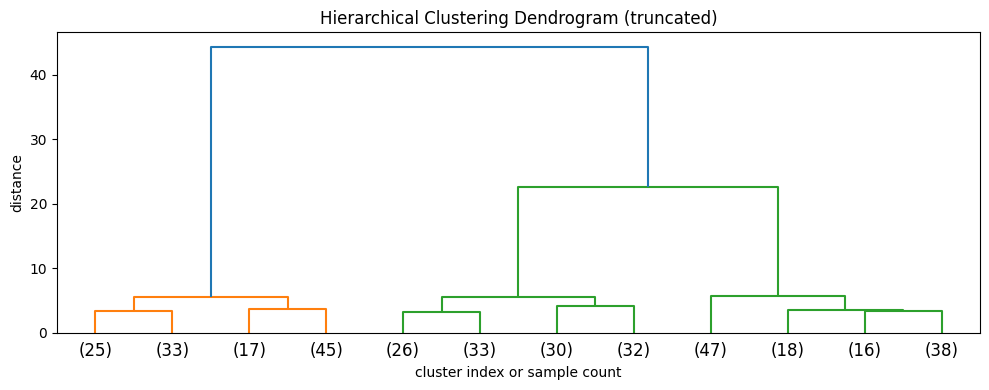

In [5]:
# 使用 Ward 链接
Z = linkage(X_scaled, method="ward")

print("linkage matrix sample:\n", Z[:5])

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=12)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("cluster index or sample count")
plt.ylabel("distance")
plt.tight_layout()
plt.show()

## 5. 训练凝聚式层次聚类模型

观察树状图后，选择 $k=3$ 作为簇数（教学演示中我们知道真实状态数）。随后查看各簇的样本数，并与“真实状态”做一个对照。

In [6]:
model = AgglomerativeClustering(n_clusters=3, linkage="ward")
cluster_label = model.fit_predict(X_scaled)

df_result = df.copy()
df_result["cluster"] = cluster_label

print("cluster counts:\n", df_result["cluster"].value_counts().sort_index())
print("\ncluster vs true_state (crosstab):\n", pd.crosstab(df_result["cluster"], df_result["true_state"]))

print("\nsample rows:\n", df_result.head())

cluster counts:
 cluster
0    119
1    120
2    121
Name: count, dtype: int64

cluster vs true_state (crosstab):
 true_state    1    2    3
cluster                  
0             1    0  118
1             0  120    0
2           119    0    2

sample rows:
         temp   humidity  vibration    pressure  true_state  cluster
0  22.745071  44.446943   0.401815  101.956909           1        2
1  21.648770  44.063452   0.476337  101.730230           1        2
2  21.295788  47.170240   0.312927  101.360281           1        2
3  22.362943  37.346879   0.212007  101.331314           1        2
4  20.480753  46.256989   0.277358  101.076309           1        2


## 6. 可视化聚类结果

使用 PCA 将 4 维数据降到 2 维，便于观察簇的分布（仅用于可视化，不参与训练）。

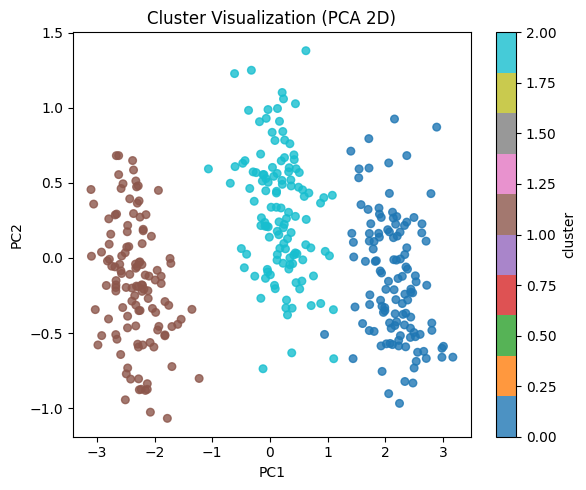

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_label, cmap="tab10", s=30, alpha=0.8)
plt.title("Cluster Visualization (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

## 7. 结果解读

- 通过树状图可以观察到在某一距离阈值处样本被明显分成 3 大簇。
- 交叉表显示聚类与模拟的真实状态高度一致，说明凝聚式层次聚类能够有效识别运行状态。
- 实际场景中，真实标签通常未知，树状图和业务先验是选择簇数的重要依据。

## 8. 拓展与思考（含解答思路）

1. **问题：** 如果把 `linkage` 从 `ward` 改为 `average` 或 `complete`，结果会有什么差异？  
   **思路：** 比较不同链接方式的树状图与聚类分布，观察簇的紧致程度和合并顺序。

2. **问题：** 在不知道簇数的真实情况下，如何选择 $k$？  
   **思路：** 结合树状图的“距离断层”、轮廓系数（silhouette score）或 Calinski-Harabasz 指标做量化对比。

3. **问题：** 如果某些传感器噪声特别大，标准化是否足够？  
   **思路：** 尝试特征选择、降维（PCA）或使用稳健标准化（RobustScaler），并比较聚类稳定性。

4. **问题：** 若数据量非常大，层次聚类计算变慢怎么办？  
   **思路：** 先用采样或小批量方法缩小规模，或用更快的聚类作为预聚类，再进行层次聚类细化。